In [1]:
# Install YOLO11 and supporting libraries

%pip install -q ultralytics opencv-python matplotlib pandas numpy tqdm

print("Libraries installed successfully.")

Note: you may need to restart the kernel to use updated packages.
Libraries installed successfully.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os
import urllib.request

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
PROJECT_NAME = "Real_Time_Traffic_Detection"

folders = [
    "data/images",
    "data/videos",
    "data/outputs",
    "models"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created.")

Project folders created.


In [4]:
image_url = "https://ultralytics.com/images/bus.jpg"

image_path = "data/images/traffic.jpg"

if not os.path.exists(image_path):
    urllib.request.urlretrieve(image_url, image_path)
    print("Image downloaded.")
else:
    print("Image already exists.")

print(image_path)

Image downloaded.
data/images/traffic.jpg


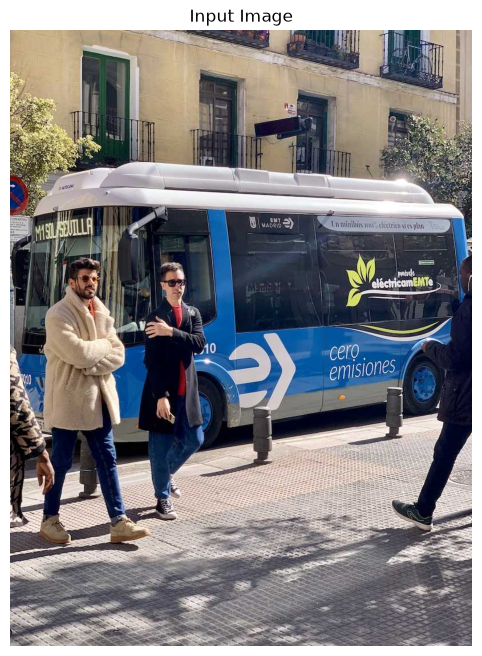

In [5]:
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,8))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [6]:
model = YOLO("yolo11n.pt")

print("YOLO11 Nano loaded successfully.")

YOLO11 Nano loaded successfully.


In [7]:
results = model(image_path)


image 1/1 d:\Computer Vision Projects\4.Real-Time Traffic Detection\notebooks\data\images\traffic.jpg: 640x480 4 persons, 1 bus, 59.2ms
Speed: 148.6ms preprocess, 59.2ms inference, 62.1ms postprocess per image at shape (1, 3, 640, 480)


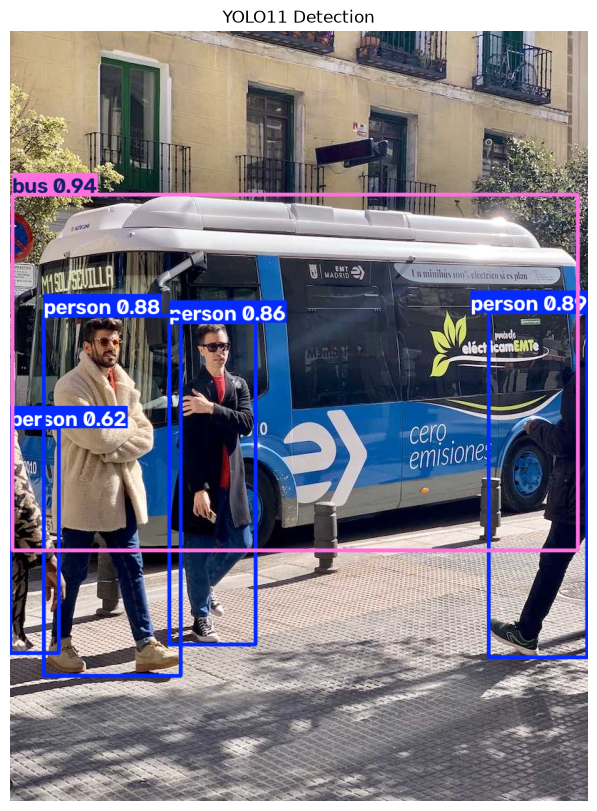

In [8]:
result = results[0]

annotated = result.plot()

annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14,10))
plt.imshow(annotated)
plt.axis("off")
plt.title("YOLO11 Detection")
plt.show()

In [9]:
for box in results[0].boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])

    print(f"{model.names[cls]:15s}  Confidence: {conf:.3f}")

bus              Confidence: 0.940
person           Confidence: 0.888
person           Confidence: 0.878
person           Confidence: 0.856
person           Confidence: 0.622


In [10]:
output_path = "data/outputs/traffic_detection.jpg"

cv2.imwrite(output_path, cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR))

print(f"Saved to: {output_path}")

Saved to: data/outputs/traffic_detection.jpg
